In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Supervised Learning/Churn_predication_project/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [47]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## handle a totalcharges feature:


In [48]:
print(df["TotalCharges"].value_counts())
print("-------------------------------")
print(df['TotalCharges'].dtype)

TotalCharges
           11
20.2       11
19.75       9
20.05       8
19.9        8
           ..
130.15      1
3211.9      1
7843.55     1
2196.3      1
197.4       1
Name: count, Length: 6531, dtype: int64
-------------------------------
object


In [49]:
#  print a row number of that have non numeric value
print(df["TotalCharges"].loc[
    pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
])

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object


In [50]:
# Convert to numerical
# here in "TotalCharges" have some blank space(Nan) for that why show dtype is object
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check null values
print(df["TotalCharges"].isnull().sum())

11


In [51]:
# remove null values :
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
df[["TotalCharges"]] = num_imputer.fit_transform(df[["TotalCharges"]])

df['TotalCharges'].isnull().sum()

np.int64(0)

In [52]:
df.shape

(7043, 21)

In [53]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [54]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2265.000258
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1400.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [56]:
# drop customer id column

df = df.drop("customerID",axis=1)

In [57]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns
print(categorical_cols)
print(numerical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


# data analyze

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Text(0.5, 1.0, 'Is churn yes or not ?')

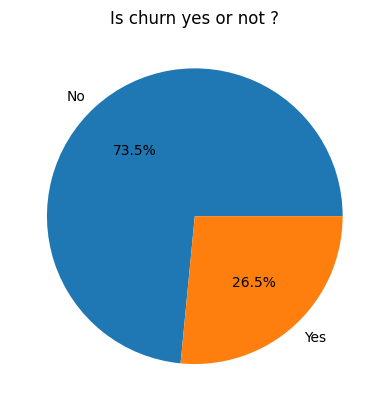

In [58]:
# how the balance classes are ?
classes_count = df['Churn'].value_counts()
print(classes_count)

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is churn yes or not ?")

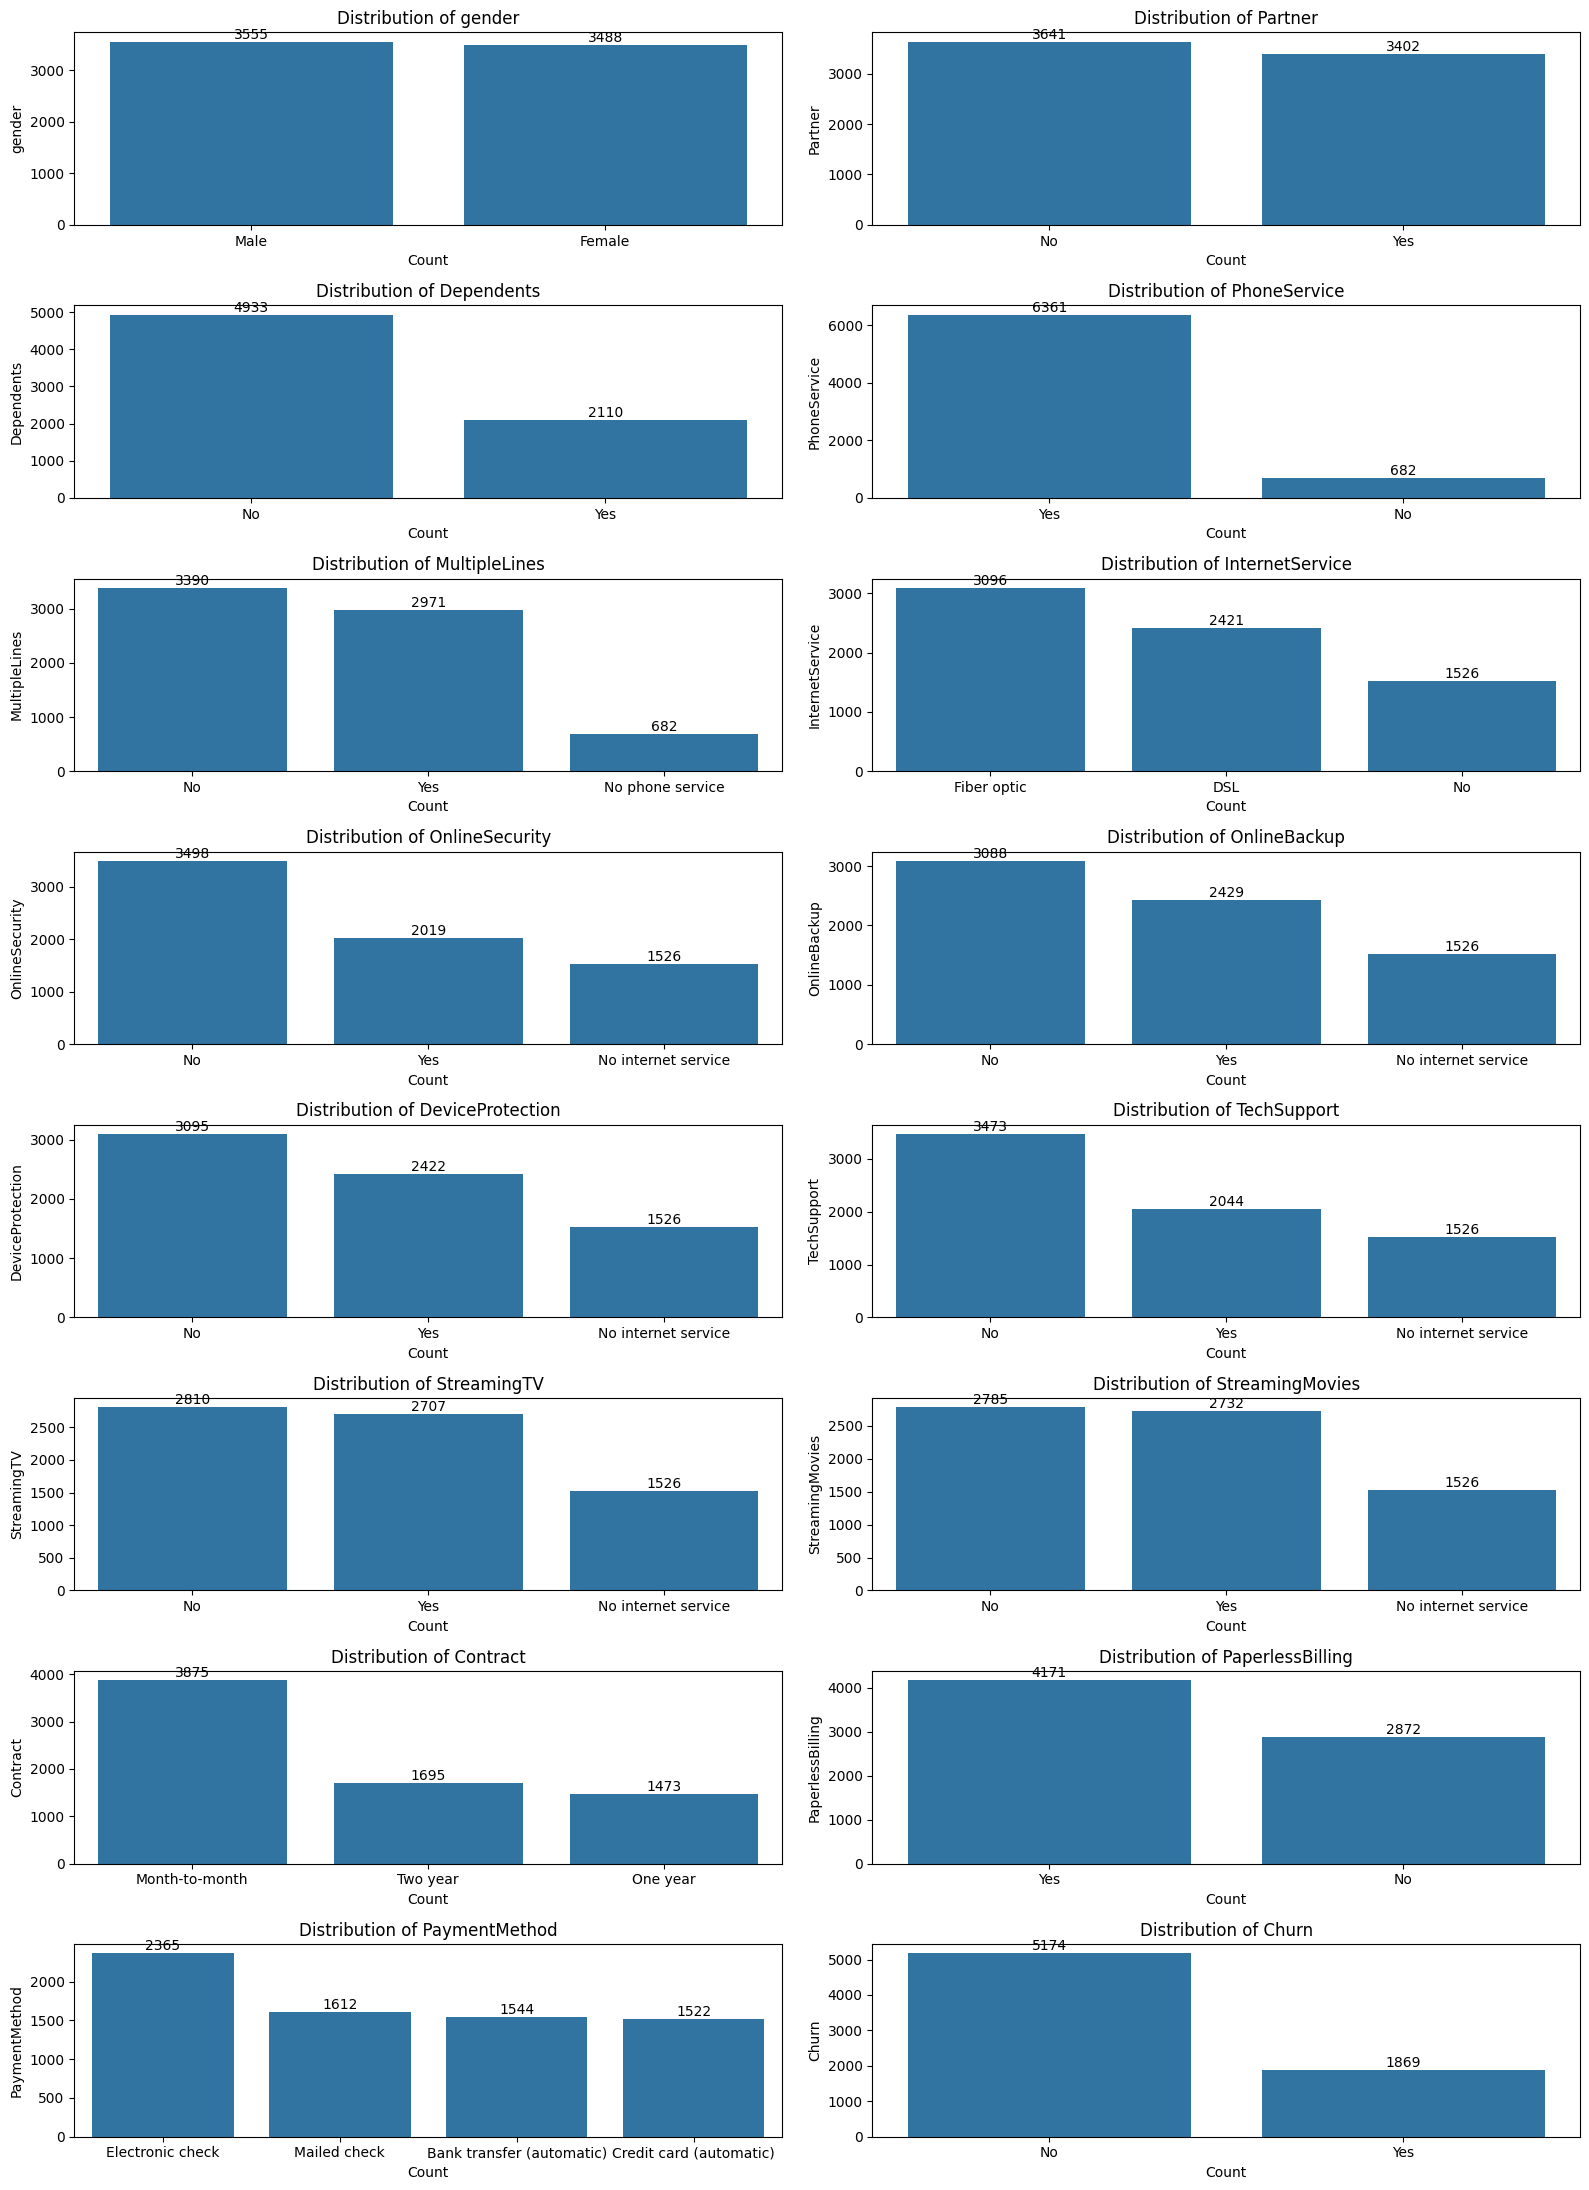

In [59]:
fig, axes = plt.subplots(
    nrows=8,
    ncols=2,
    figsize=(16, 22)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    counts = df[col].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(col)

    axes[i].bar_label(axes[i].containers[0])

plt.tight_layout()
plt.show()

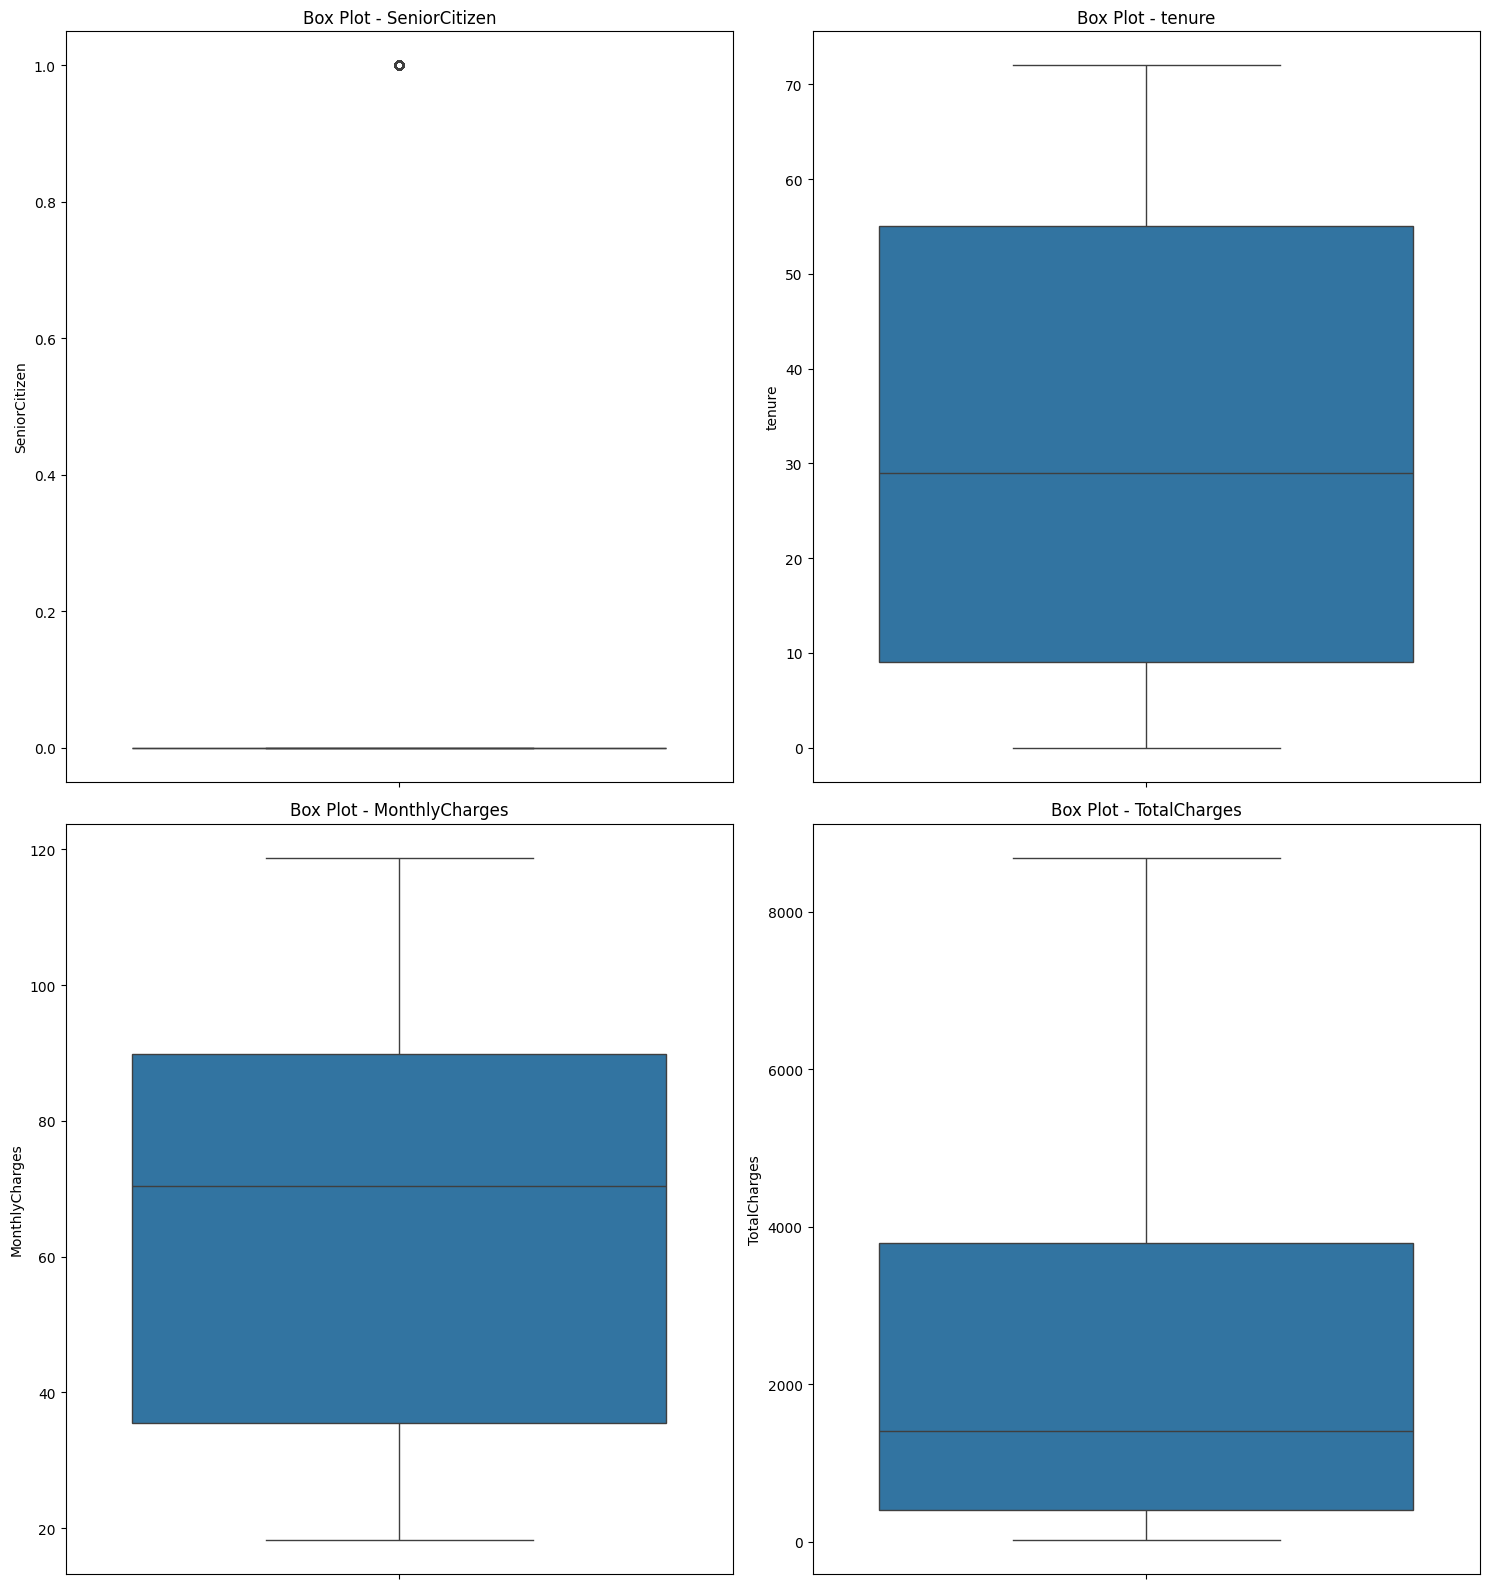

In [60]:
# check outliers in numerical columns
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 16)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Box Plot - {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [61]:
print(df["SeniorCitizen"].value_counts())
print("-------------------------------")
print(df['SeniorCitizen'].dtype)


# here the ecoding is already given in dataset

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
-------------------------------
int64


# Encoding (Feature Encoding)

In [62]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [63]:
for i in categorical_cols:
  print(df[i].value_counts())
  print("-------------------------------")


gender
Male      3555
Female    3488
Name: count, dtype: int64
-------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64
-------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
-------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
-------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
-------------------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
-------------------------------
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
-------------------------------
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
-------------------------------
DeviceProtection
No               

In [64]:
print(categorical_cols.values)

['gender' 'Partner' 'Dependents' 'PhoneService' 'MultipleLines'
 'InternetService' 'OnlineSecurity' 'OnlineBackup' 'DeviceProtection'
 'TechSupport' 'StreamingTV' 'StreamingMovies' 'Contract'
 'PaperlessBilling' 'PaymentMethod' 'Churn']


In [65]:
# for OneHotEncoding
nominal_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']

#for LabelEncoding
ordinal_cols = ["Contract","Churn" ]

In [66]:
le = LabelEncoder()

for col in ordinal_cols:
  df[col] = le.fit_transform(df[col])

In [67]:
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded_array = ohe.fit_transform(df[nominal_cols]) #here return nd array

encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(nominal_cols), index=df.index)

df = df.drop(nominal_cols, axis=1) # drop a previous columns

df = pd.concat([df, encoded_df], axis=1) # concatination old dataset to new dataframes

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   Contract                               7043 non-null   int64  
 3   MonthlyCharges                         7043 non-null   float64
 4   TotalCharges                           7043 non-null   float64
 5   Churn                                  7043 non-null   int64  
 6   gender_Male                            7043 non-null   float64
 7   Partner_Yes                            7043 non-null   float64
 8   Dependents_Yes                         7043 non-null   float64
 9   PhoneService_Yes                       7043 non-null   float64
 10  MultipleLines_No phone service         7043 non-null   float64
 11  Mult

# train & test split

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X = df.drop("Churn",axis=1)
y=df['Churn']

print(X.shape)
print(y.shape)

(7043, 29)
(7043,)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(5634, 29)
(1409, 29)


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<Axes: >

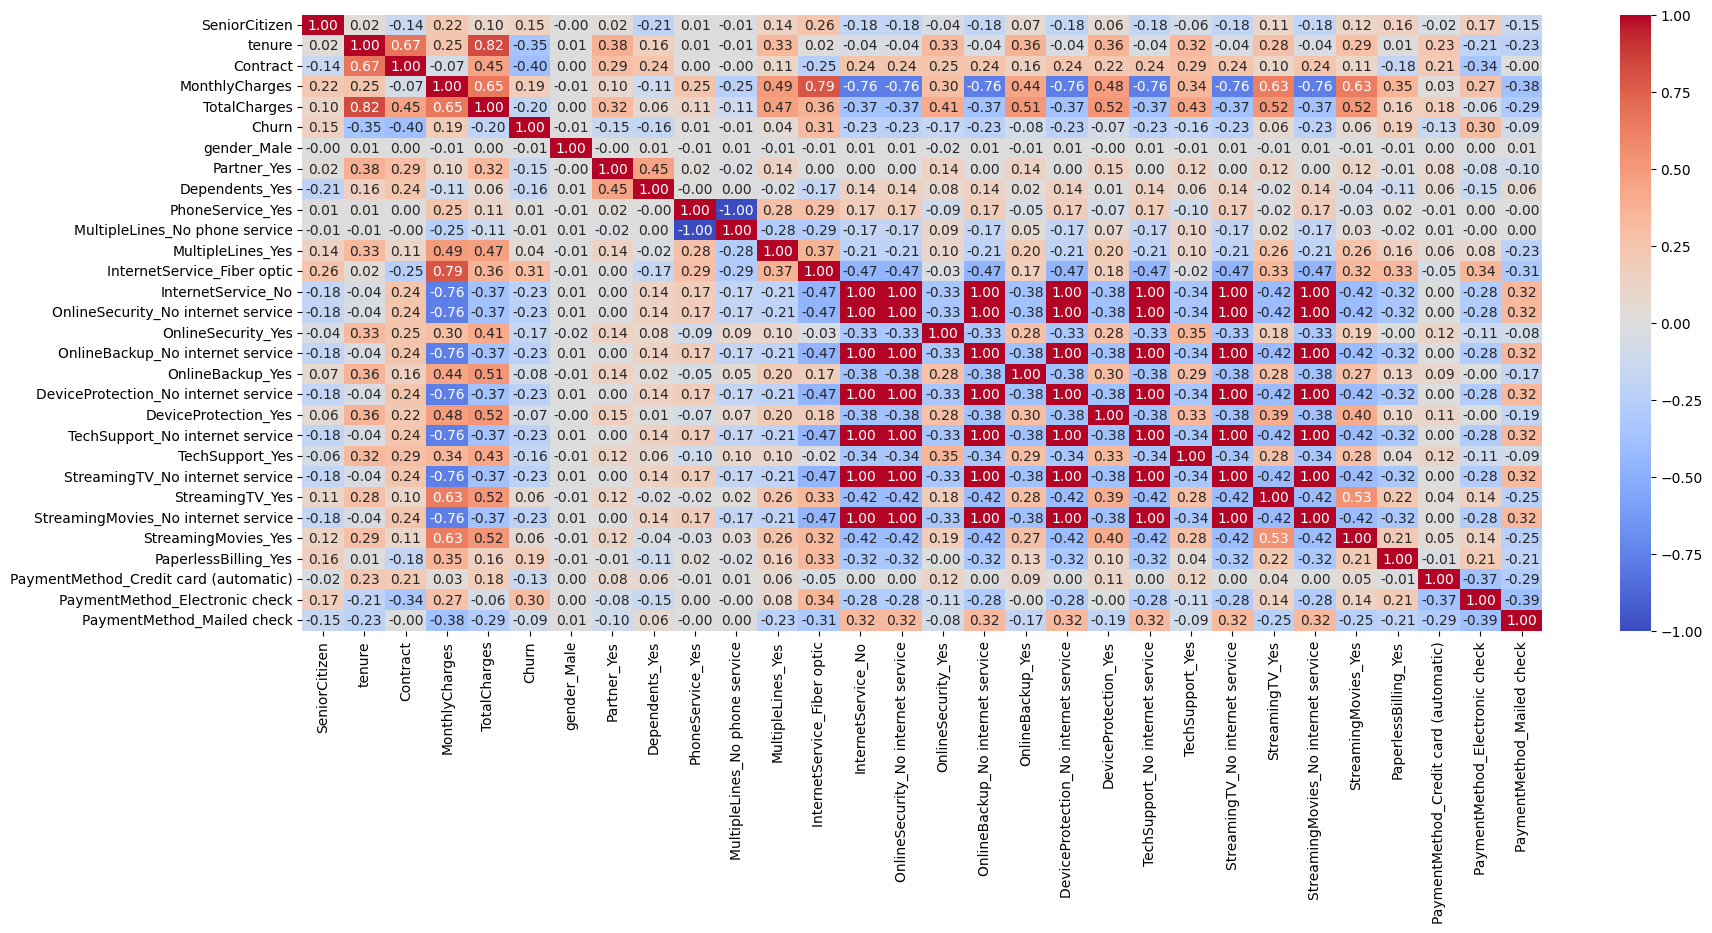

In [73]:
num_cols = df.select_dtypes(include="number")

corr_matrix = num_cols.corr()

# print(corr_matrix)
plt.figure(figsize=(20, 8))
sns.heatmap(
  corr_matrix,
  annot= True,
  fmt=".2f",
  cmap="coolwarm"
)

In [74]:
num_cols.corr()["Churn"].sort_values(ascending = False)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling_Yes,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
PhoneService_Yes,0.011942


# Train && Evaluate Model

In [75]:
#  logistic regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)


In [76]:
# KNN classification
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier(n_neighbors=7)

knn_classifier.fit(X_train, y_train)

knn_pred = knn_classifier.predict(X_test)

In [77]:
# Naive Bayes classification

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [78]:
# desion Tree model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=6,min_samples_split=25)
dt_model.fit(X_train, y_train)

dt_y_pred = dt_model.predict(X_test)

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=50, random_state=42)

rf_classifier.fit(X_train, y_train)

rf_y_pred = rf_classifier.predict(X_test)

In [80]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

print("Logistic Regression Metrics:")
print("Precision : ",precision_score(y_test, log_pred))
print("Recall : ",recall_score(y_test, log_pred))
print("Accuracy : ",accuracy_score(y_test, log_pred))
print("CM :", confusion_matrix(y_test, log_pred))

print("\n-----------------------------------------------------------\n")
print("KNN Classification Metrics:")
print("Precision : ",precision_score(y_test, knn_pred))
print("Recall : ",recall_score(y_test, knn_pred))
print("Accuracy : ",accuracy_score(y_test, knn_pred))
print("CM :", confusion_matrix(y_test, knn_pred))

print("\n-----------------------------------------------------------\n")
print("Naive Bayes Classification Metrics:")
print("Precision : ",precision_score(y_test, nb_pred))
print("Recall : ",recall_score(y_test, nb_pred))
print("Accuracy : ",accuracy_score(y_test, nb_pred))
print("CM :", confusion_matrix(y_test, nb_pred))

print("\n-----------------------------------------------------------\n")
print("Decision Tree Classification Metrics:")
print("Precision : ",precision_score(y_test, dt_y_pred))
print("Recall : ",recall_score(y_test, dt_y_pred))
print("Accuracy : ",accuracy_score(y_test, dt_y_pred))
print("CM :", confusion_matrix(y_test, dt_y_pred))

print("\n---------------------------------------------------------")
print("Random Forest Classification Metrics:")
print("Precision : ",precision_score(y_test, rf_y_pred))
print("Recall : ",recall_score(y_test, rf_y_pred))
print("Accuracy : ",accuracy_score(y_test, rf_y_pred))
print("CM :", confusion_matrix(y_test, rf_y_pred))

Logistic Regression Metrics:
Precision :  0.6840490797546013
Recall :  0.5978552278820375
Accuracy :  0.8204400283889283
CM : [[933 103]
 [150 223]]

-----------------------------------------------------------

KNN Classification Metrics:
Precision :  0.5854430379746836
Recall :  0.4959785522788204
Accuracy :  0.7735982966643009
CM : [[905 131]
 [188 185]]

-----------------------------------------------------------

Naive Bayes Classification Metrics:
Precision :  0.4351245085190039
Recall :  0.8900804289544236
Accuracy :  0.6650106458481192
CM : [[605 431]
 [ 41 332]]

-----------------------------------------------------------

Decision Tree Classification Metrics:
Precision :  0.6813559322033899
Recall :  0.5388739946380697
Accuracy :  0.8112136266855926
CM : [[942  94]
 [172 201]]

---------------------------------------------------------
Random Forest Classification Metrics:
Precision :  0.674074074074074
Recall :  0.4879356568364611
Accuracy :  0.8019872249822569
CM : [[948  88]

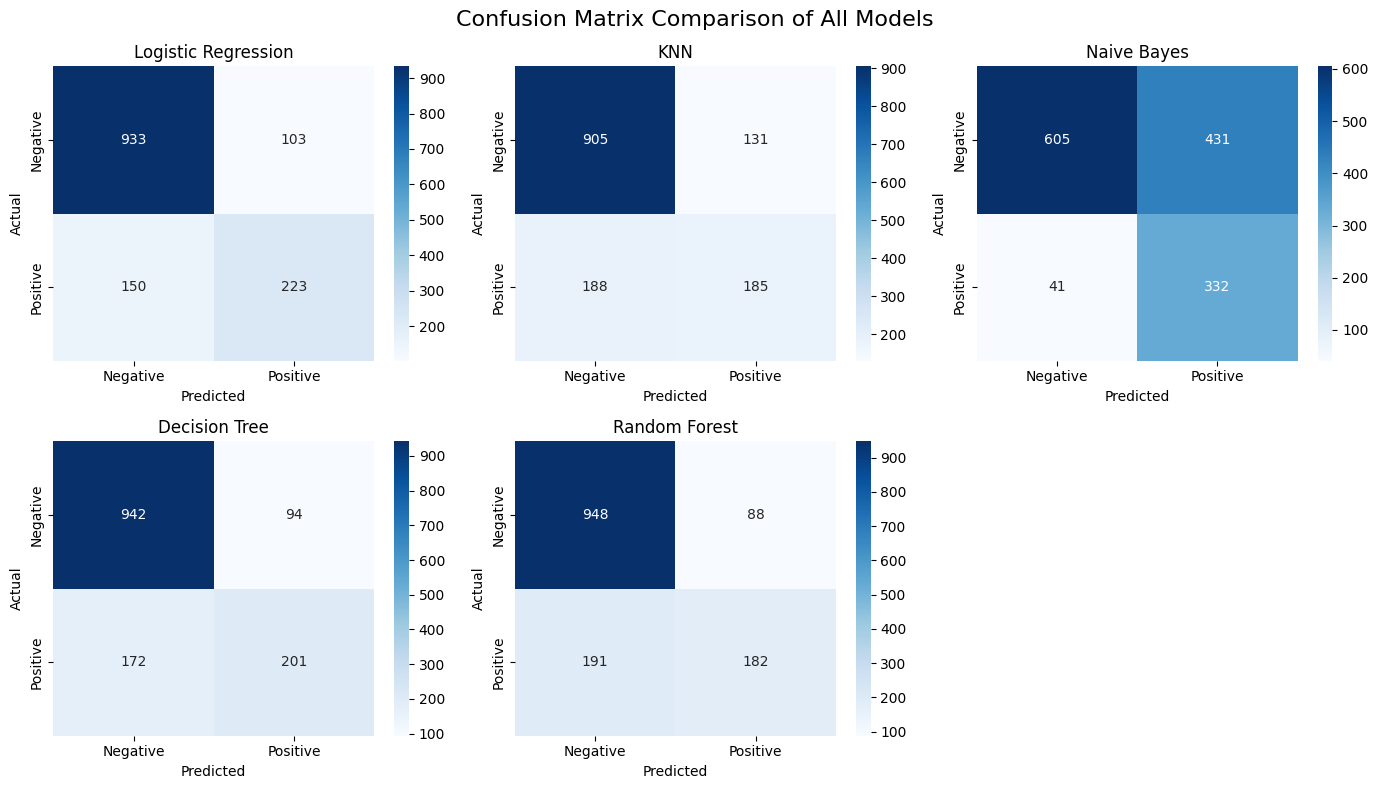

In [81]:

# Store model names and predictions
models = {
    "Logistic Regression": log_pred,
    "KNN": knn_pred,
    "Naive Bayes": nb_pred,
    "Decision Tree": dt_y_pred,
    "Random Forest": rf_y_pred
}

# Create one figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Flatten axes so we can loop easily
axes = axes.flatten()

for ax, (name, pred) in zip(axes, models.items()):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Hide the unused 6th subplot
axes[5].axis("off")

plt.suptitle("Confusion Matrix Comparison of All Models", fontsize=16)
plt.tight_layout()
plt.show()